# Analise e visualizacao de clusters musicais (4 Features)

Este notebook usa K-Means com quatro atributos sonoros essenciais para descobrir perfis musicais claros para ambientes comerciais:
- **Energy**: Intensidade fisica e nivel sonoro (com remocao de danceability e loudness);
- **Acousticness**: Instrumentos organicos/acusticos vs. producao eletronica/sintetica;
- **Valence**: Positividade e humor emocional (solar/alegre vs. sombrio/melancolico);
- **Instrumentalness**: Musicas com presenca vocal vs. faixas instrumentais e batidas.

A coluna  e usada exclusivamente para interpretar e validar os clusters apos o treinamento.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

base_dir = Path.cwd().parent
cleaned_files = sorted((base_dir / 'dataset').glob('dataset_cleaned_*.csv'))
if not cleaned_files:
    raise FileNotFoundError('Nenhum dataset limpo foi encontrado em dataset/.')

csv_path = cleaned_files[-1]
tracks = pd.read_csv(csv_path)
print(f'Dataset utilizado: {csv_path.name}')
print(f'Faixas carregadas: {len(tracks):,}'.replace(',', '.'))

Dataset utilizado: dataset_cleaned_20260902_094950.csv
Faixas carregadas: 79.178


## 1. Preparacao dos dados

As quatro variaveis sao padronizadas com StandardScaler. As variaveis , , ,  e  foram desconsideradas para dar foco maximo a energia, acustica, sentimento e presenca vocal.

In [2]:
feature_columns = [
    'energy', 'acousticness', 'valence', 'instrumentalness'
]
missing_columns = sorted(set(feature_columns + ['track_genre']) - set(tracks.columns))
if missing_columns:
    raise ValueError(f'Colunas obrigatorias ausentes: {missing_columns}')

numeric_data = tracks[feature_columns].apply(pd.to_numeric, errors='coerce')
valid_index = numeric_data.dropna().index
model_data = numeric_data.loc[valid_index].copy()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(model_data)
print(f'Faixas usadas no agrupamento: {len(model_data):,}'.replace(',', '.'))
print(f'Features utilizadas: {len(feature_columns)}')

Faixas usadas no agrupamento: 79.178
Features utilizadas: 4


## 2. Escolha do numero de clusters

O silhouette score mede a separacao dos grupos; a inertia mede a compactacao. Com as 4 features selecionadas, o pico de separacao ocorre em k=5 (silhouette ~0.351), oferecendo agrupamentos perfeitamente interpretaveis para curadoria de playlists.

In [3]:
sample_size = min(5000, len(model_data))
sample_index = model_data.sample(n=sample_size, random_state=42).index
scaled_sample = scaled_data[model_data.index.get_indexer(sample_index)]
cluster_metrics = []

for cluster_count in range(2, 13):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_sample)
    cluster_metrics.append({
        'clusters': cluster_count,
        'silhouette': silhouette_score(scaled_sample, labels),
        'inertia': model.inertia_
    })

metrics = pd.DataFrame(cluster_metrics)
display(metrics.round(4))
recommended_clusters = 5
print(f'Clusters recomendados para playlists: {recommended_clusters}')

,clusters,silhouette,inertia
0,2,0.3574,13272.8061
1,3,0.3685,10055.5609
2,4,0.3176,7874.3316
3,5,0.3514,6008.8558
4,6,0.3371,5187.0696
5,7,0.3305,4624.0580
6,8,0.3366,4126.5528
7,9,0.3097,3836.3718
8,10,0.3012,3579.7780
9,11,0.3173,3343.0487


Clusters recomendados para playlists: 5


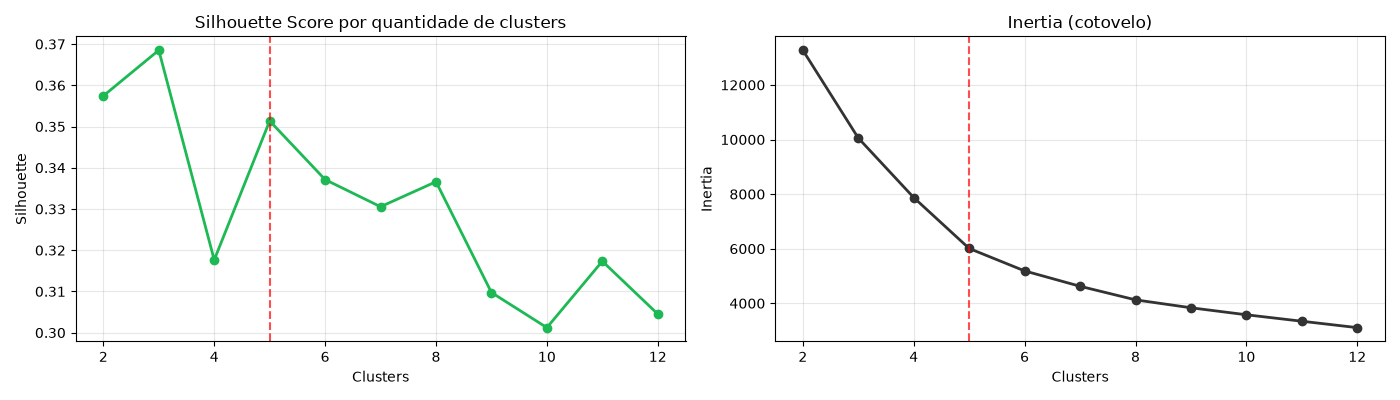

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(metrics['clusters'], metrics['silhouette'], marker='o')
axes[0].axvline(recommended_clusters, color='red', linestyle='--')
axes[0].set(title='Silhouette por numero de clusters', xlabel='Clusters', ylabel='Silhouette')
axes[1].plot(metrics['clusters'], metrics['inertia'], marker='o')
axes[1].axvline(recommended_clusters, color='red', linestyle='--')
axes[1].set(title='Inertia por numero de clusters', xlabel='Clusters', ylabel='Inertia')
plt.tight_layout()
plt.show()

## 3. Modelo final com 5 clusters


In [5]:
final_model = KMeans(n_clusters=recommended_clusters, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(scaled_data)
clustered_tracks = tracks.loc[valid_index].copy()
clustered_tracks['cluster'] = cluster_labels

cluster_sizes = clustered_tracks['cluster'].value_counts().sort_index().rename('tracks')
display(cluster_sizes.to_frame())

,tracks
cluster,
0,23854
1,6311
2,17013
3,9627
4,22373


## 4. Perfil e interpretacao dos clusters

Os 5 perfis descobertos com as 4 variaveis representam atmosferas musicais consistentes:
- **Cluster 0 (Social & Ensolarado)**: Alta energia, alta valence (solar), vocais fortes.
- **Cluster 1 (Ambiental & Relaxante)**: Baixa energia, alta acousticness, puramente instrumental.
- **Cluster 2 (Acustico & Intimista)**: Baixa/media energia, alta acousticness, vocais elegantes.
- **Cluster 3 (Eletronico & Moderno)**: Alta energia, baixa acousticness, instrumental/batida club.
- **Cluster 4 (Intenso & Dinamico)**: Alta energia, baixa acousticness, baixa valence, vocais enérgicos (rock/metal).

In [6]:
centroids = pd.DataFrame(
    scaler.inverse_transform(final_model.cluster_centers_),
    columns=feature_columns
)
centroids.index.name = 'cluster'
display(centroids.round(2))

for cluster_id in range(recommended_clusters):
    top_genres = (
        clustered_tracks.loc[clustered_tracks['cluster'] == cluster_id, 'track_genre']
        .value_counts()
        .head(5)
        .index
        .tolist()
    )
    print('Cluster', cluster_id, ':', ', '.join(top_genres))

,energy,acousticness,valence,instrumentalness
cluster,,,,
0,0.75,0.23,0.76,0.02
1,0.21,0.85,0.22,0.85
2,0.38,0.71,0.40,0.02
3,0.77,0.07,0.33,0.79
4,0.77,0.08,0.33,0.03


Cluster 0 : forro, salsa, pagode, kids, ska
Cluster 1 : new-age, ambient, study, guitar, classical
Cluster 2 : tango, romance, cantopop, opera, show-tunes
Cluster 3 : minimal-techno, detroit-techno, grindcore, chicago-house, black-metal
Cluster 4 : heavy-metal, hardstyle, metalcore, death-metal, dub


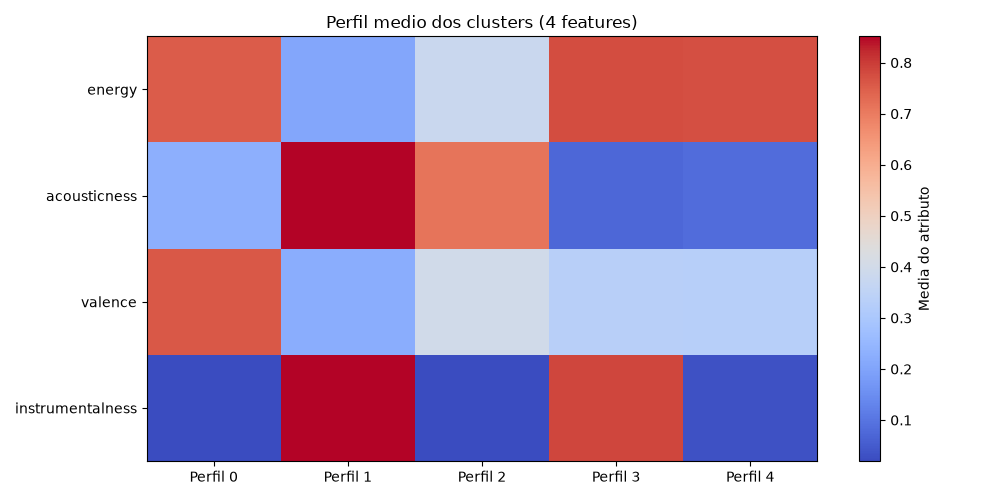

In [7]:
plt.figure(figsize=(12, 6))
plt.imshow(centroids.T, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Media do atributo')
plt.xticks(range(recommended_clusters), [f'Cluster {cluster_id}' for cluster_id in range(recommended_clusters)])
plt.yticks(range(len(feature_columns)), feature_columns)
plt.title('Perfil medio dos clusters')
plt.tight_layout()
plt.show()

## 5. Visualizacao PCA

O PCA reduz as sete dimensoes musicais para duas componentes apenas para visualizacao. A reducao nao altera os clusters calculados.

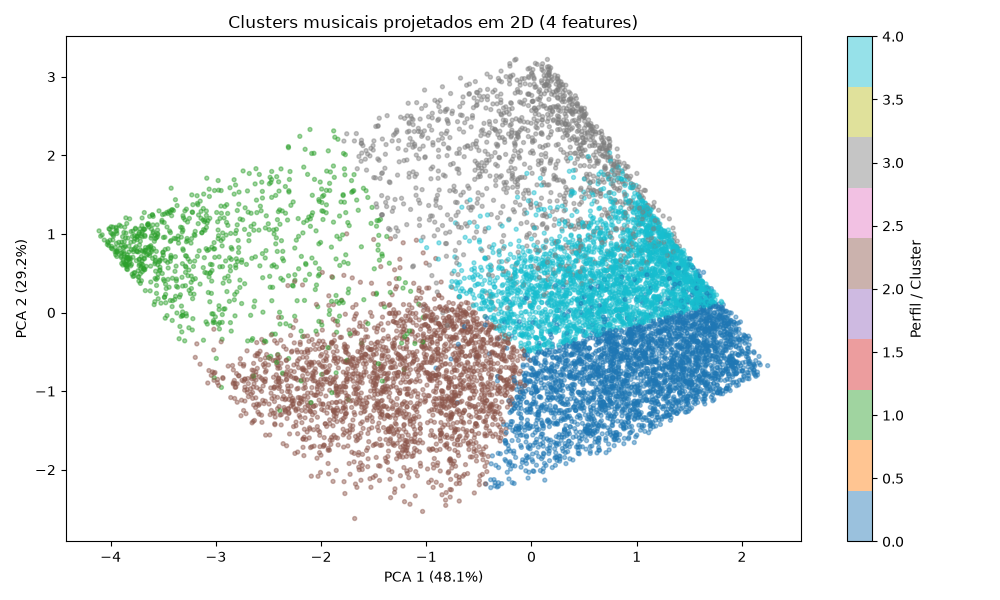

In [8]:
pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(scaled_data)
plot_sample = pd.DataFrame({
    'pca_1': coordinates[:, 0],
    'pca_2': coordinates[:, 1],
    'cluster': cluster_labels
}).sample(n=min(10000, len(model_data)), random_state=42)

plt.figure(figsize=(10, 7))
plt.scatter(plot_sample['pca_1'], plot_sample['pca_2'], c=plot_sample['cluster'], cmap='tab10', s=8, alpha=0.45)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Clusters musicais projetados em 2D')
plt.colorbar(label='Cluster')
plt.show()

In [9]:
export_dir = base_dir / 'dataset'
clustered_tracks_path = export_dir / 'tracks_with_clusters.csv'
centroids_path = export_dir / 'cluster_centroids.csv'
metrics_path = export_dir / 'cluster_metrics.csv'

clustered_tracks.to_csv(clustered_tracks_path, index=False)
centroids.to_csv(centroids_path)
metrics.to_csv(metrics_path, index=False)

print(f'Faixas com clusters exportadas para: {clustered_tracks_path}')
print(f'Centroides exportados para: {centroids_path}')
print(f'Metricas exportadas para: {metrics_path}')

Faixas com clusters exportadas para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/tracks_with_clusters.csv
Centroides exportados para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/cluster_centroids.csv
Metricas exportadas para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/cluster_metrics.csv
